Collecting milestone 2 trained models and milestone 1 processed test data to start distributed prediction and aggregation for milestone 3.

In [7]:

import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz

from dask.distributed import Client, as_completed

np.random.seed(42)

ROOT = Path(".")
TEST_NPZ = ROOT / "X_test_normalized.npz"
TEST_META = ROOT / "test_meta.csv"
MODELS_DIR = ROOT / "models_node_level"
MODEL_REGISTRY = MODELS_DIR / "model_registry.csv"
NODE_SUMMARY = MODELS_DIR / "node_training_summary.csv"
MANIFEST_M3 = ROOT / "milestone3_manifest.json"

required = [TEST_NPZ, TEST_META, MODELS_DIR, MODEL_REGISTRY, NODE_SUMMARY]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required milestone files:\n" + "\n".join(missing) +
        "\nRun milestone1.ipynb and milestone2.ipynb fully before milestone3."
    )

print("Milestone 3 prerequisites found.")
print(f"Test features file    : {TEST_NPZ}")
print(f"Test metadata file    : {TEST_META}")
print(f"Model registry file   : {MODEL_REGISTRY}")
print(f"Node summary file     : {NODE_SUMMARY}")


Milestone 3 prerequisites found.
Test features file    : X_test_normalized.npz
Test metadata file    : test_meta.csv
Model registry file   : models_node_level\model_registry.csv
Node summary file     : models_node_level\node_training_summary.csv


Loading sparse test features, metadata, and verified model registry to prepare inference inputs and aggregation tracking structures.

In [8]:

X_test_sparse = load_npz(TEST_NPZ).tocsr()
df_test_meta = pd.read_csv(TEST_META)
node_summary_df = pd.read_csv(NODE_SUMMARY)
registry_df = pd.read_csv(MODEL_REGISTRY)

if "integrity" in registry_df.columns:
    trained_rows = registry_df[registry_df["integrity"] == "OK"].copy()
else:
    trained_rows = registry_df.copy()

if trained_rows.empty:
    raise ValueError("No verified trained model rows found in model_registry.csv")

if "row_id" in df_test_meta.columns:
    row_ids = df_test_meta["row_id"].astype(str).tolist()
else:
    row_ids = [str(i) for i in range(X_test_sparse.shape[0])]

print(f"Test feature matrix shape : {X_test_sparse.shape}")
print(f"Test metadata rows        : {len(df_test_meta)}")
print(f"Verified model entries    : {len(trained_rows)}")
print(f"Expected trained labels   : {int(node_summary_df['trained_labels'].sum())}")


Test feature matrix shape : (3971, 5000)
Test metadata rows        : 3971
Verified model entries    : 3644
Expected trained labels   : 3644


Connecting to the live Dask scheduler and scattering test features once so worker nodes can run parallel inference efficiently.

In [11]:

SCHEDULER_IP = "192.168.1.106"  # replace if needed
SCHEDULER_PORT = 8786

print(f"Connecting to scheduler at tcp://{SCHEDULER_IP}:{SCHEDULER_PORT} ...")
client = Client(f"tcp://{SCHEDULER_IP}:{SCHEDULER_PORT}")

scheduler_info = client.scheduler_info()
active_workers = list(scheduler_info["workers"].keys())

if not active_workers:
    raise RuntimeError("No active workers connected to scheduler. Start worker nodes first.")

print(f"Connected workers: {len(active_workers)}")
for w in active_workers:
    print(f"  {w}")
print(f"Dashboard: {client.dashboard_link}")

print("Scattering test features to workers...")
_scatter_start = time.time()
X_test_ref = client.scatter(X_test_sparse, broadcast=True)
scatter_time_sec = round(time.time() - _scatter_start, 3)
print(f"Test matrix scattered successfully.")
print(f"Scatter time: {scatter_time_sec}s  "
      f"({X_test_sparse.data.nbytes/1e6:.1f} MB transferred)")


Connecting to scheduler at tcp://192.168.1.106:8786 ...
Connected workers: 2
  tcp://192.168.1.125:58022
  tcp://192.168.1.126:60486
Dashboard: http://192.168.1.106:8787/status
Scattering test features to workers...
Test matrix scattered successfully.
Scatter time: 6.101s  (7.4 MB transferred)


In [15]:

# Install scipy and scikit-learn on all workers if missing
print("Installing dependencies on all workers...")
def install_deps():
    missing = []
    try:
        import scipy
    except ImportError:
        missing.append("scipy")
    try:
        import sklearn
    except ImportError:
        missing.append("scikit-learn")
    
    if missing:
        import subprocess
        import sys
        for pkg in missing:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return f"installed: {', '.join(missing)}"
    return "all dependencies already installed"

results = client.run(install_deps)
for worker, msg in results.items():
    print(f"  {worker}: {msg}")



Installing dependencies on all workers...
  tcp://192.168.1.125:58022: installed: scikit-learn
  tcp://192.168.1.126:60486: all dependencies already installed


Collecting model payload bytes from milestone 2 artifacts and preparing label batches for distributed prediction dispatch.

In [12]:

def parse_label_id(label_name: str) -> int:
    s = str(label_name)
    if s.startswith("label_"):
        return int(s.split("_")[1])
    return int(s)

model_payload_items = []
missing_model_paths = []

for _, row in trained_rows.iterrows():
    label_col = str(row["label"])
    model_path = Path(row["model_path"])
    if not model_path.exists():
        missing_model_paths.append(str(model_path))
        continue
    with open(model_path, "rb") as f:
        model_bytes = f.read()
    model_payload_items.append((label_col, parse_label_id(label_col), model_bytes))

if missing_model_paths:
    print(f"Warning: missing model files: {len(missing_model_paths)}")
    print("First few missing paths:")
    print(missing_model_paths[:5])

if not model_payload_items:
    raise ValueError("No model payloads available for inference.")

model_payload_items = sorted(model_payload_items, key=lambda x: x[1])
print(f"Model payloads prepared: {len(model_payload_items)}")
print(f"First labels: {[x[0] for x in model_payload_items[:5]]}")


Model payloads prepared: 3644
First labels: ['label_0', 'label_1', 'label_2', 'label_3', 'label_4']


Implementing worker-side inference and returning compact batch outputs for threshold aggregation and fallback label selection.

In [13]:

def predict_label_batch_worker(batch_items, x_eval, threshold=0.5):
    import pickle
    import numpy as np

    n_rows = x_eval.shape[0]
    positive_map = {}
    best_scores = np.full(n_rows, -1.0, dtype=np.float32)
    best_labels = np.full(n_rows, -1, dtype=np.int32)

    for label_col, label_id, model_bytes in batch_items:
        model = pickle.loads(model_bytes)
        probs = model.predict_proba(x_eval)[:, 1].astype(np.float32)
        pos_idx = np.where(probs >= threshold)[0]
        if pos_idx.size > 0:
            for idx in pos_idx:
                if idx not in positive_map:
                    positive_map[idx] = [int(label_id)]
                else:
                    positive_map[idx].append(int(label_id))

        better = probs > best_scores
        best_scores[better] = probs[better]
        best_labels[better] = int(label_id)

    return {
        "positive_map": positive_map,
        "best_scores": best_scores,
        "best_labels": best_labels,
        "labels_processed": len(batch_items),
        "rows": n_rows,
    }


Executing distributed inference across available workers, aggregating thresholded outputs, applying fallback labels, and writing final prediction files.

In [16]:

THRESHOLD = 0.5
PREDICTION_CSV = ROOT / "milestone3_predictions.csv"
PREDICTION_PARQUET = ROOT / "milestone3_predictions.parquet"

n_workers = len(active_workers)
n_rows = X_test_sparse.shape[0]

# Split labels into one batch per active worker
batch_arrays = np.array_split(np.array(model_payload_items, dtype=object), n_workers)
batches = [arr.tolist() for arr in batch_arrays if len(arr) > 0]

row_positive_labels = [[] for _ in range(n_rows)]
global_best_scores = np.full(n_rows, -1.0, dtype=np.float32)
global_best_labels = np.full(n_rows, -1, dtype=np.int32)

futures = []
inference_start = time.time()

for i, batch in enumerate(batches):
    worker_addr = active_workers[i % n_workers]
    fut = client.submit(
        predict_label_batch_worker,
        batch,
        X_test_ref,
        THRESHOLD,
        workers=[worker_addr],
        pure=False,
    )
    futures.append(fut)

print(f"Dispatched {len(futures)} distributed inference tasks.")

labels_processed_total = 0
for fut in as_completed(futures):
    out = fut.result()
    labels_processed_total += int(out["labels_processed"])

    pos_map = out["positive_map"]
    for row_idx, lbls in pos_map.items():
        row_positive_labels[int(row_idx)].extend(lbls)

    batch_best_scores = out["best_scores"]
    batch_best_labels = out["best_labels"]
    better = batch_best_scores > global_best_scores
    global_best_scores[better] = batch_best_scores[better]
    global_best_labels[better] = batch_best_labels[better]

inference_time_distributed = round(time.time() - inference_start, 3)

# Aggregation strategy:
# 1) thresholding per label (>= THRESHOLD)
# 2) fallback to best-probability label if row has no positive labels
predicted_labels_text = []
predicted_label_count = []
empty_before_fallback = 0

for i in range(n_rows):
    labels = sorted(set(row_positive_labels[i]))
    if len(labels) == 0:
        empty_before_fallback += 1
        if global_best_labels[i] >= 0:
            labels = [int(global_best_labels[i])]

    predicted_labels_text.append(" ".join([f"{lbl}:1" for lbl in labels]))
    predicted_label_count.append(len(labels))

predictions_df = pd.DataFrame({
    "row_id": row_ids,
    "predicted_labels": predicted_labels_text,
    "predicted_label_count": predicted_label_count,
})

predictions_df.to_csv(PREDICTION_CSV, index=False)

parquet_written = False
try:
    predictions_df.to_parquet(PREDICTION_PARQUET, index=False)
    parquet_written = True
except Exception as e:
    print(f"Parquet write skipped: {e}")

print("Distributed inference complete.")
print(f"Labels processed               : {labels_processed_total}")
print(f"Test rows predicted            : {len(predictions_df)}")
print(f"Rows empty before fallback     : {empty_before_fallback}")
print(f"Distributed inference time (s) : {inference_time_distributed}")
print(f"Predictions CSV saved          : {PREDICTION_CSV}")
if parquet_written:
    print(f"Predictions Parquet saved      : {PREDICTION_PARQUET}")

display(predictions_df.head(10))


Dispatched 2 distributed inference tasks.
Distributed inference complete.
Labels processed               : 3644
Test rows predicted            : 3971
Rows empty before fallback     : 2
Distributed inference time (s) : 38.083
Predictions CSV saved          : milestone3_predictions.csv
Predictions Parquet saved      : milestone3_predictions.parquet


,row_id,predicted_labels,predicted_label_count
0,0,1617:1 1621:1 2145:1 2301:1 3216:1 3227:1 3229...,8
1,1,61:1 186:1 752:1 895:1 1551:1 1843:1 1939:1 19...,19
2,2,102:1 278:1 621:1 670:1 793:1 899:1 997:1 1188...,24
3,3,77:1 80:1 254:1 303:1 329:1 347:1 420:1 489:1 ...,33
4,4,435:1 536:1 571:1 674:1 750:1 764:1 956:1 1120...,37
5,5,151:1 249:1 255:1 454:1 477:1 534:1 637:1 882:...,33
6,6,93:1 174:1 226:1 306:1 454:1 672:1 1022:1 1143...,21
7,7,340:1 1338:1 1521:1 1663:1 2172:1 2719:1 3081:...,8
8,8,21:1 254:1 313:1 332:1 336:1 390:1 391:1 430:1...,40
9,9,166:1 335:1 686:1 960:1 1397:1 1625:1 1753:1 2...,13


Benchmarking sequential and distributed inference to measure runtime, speedup, and parallel efficiency across available worker counts.

Loaded sequential_benchmark.json — serial fraction = 0.38467061568838634
Sequential benchmark — labels: 300  time: 1.979s
Worker counts to test: [1, 2]


c:\Users\786 Computers\Desktop\distributed-binary-relevance\.venv\Lib\site-packages\distributed\client.py:3398: UserWarning: Sending large graph of size 11.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Workers=1 | dist=2.446s | speedup=0.809 | eff=0.809
  Workers=2 | dist=7.616s | speedup=0.260 | eff=0.130

Benchmark results saved: milestone3_benchmark.csv


,worker_count,seq_time_sec,dist_time_sec,scatter_time_sec,compute_time_sec,speedup,efficiency,comm_fraction,seq_positive_count,dist_positive_count
0,1,1.979,2.446,6.101,0.000,0.8091,0.8091,0.7138,16247,16247
1,2,1.979,7.616,6.101,1.515,0.2598,0.1299,0.4448,16247,16247


Serial fraction used for Amdahl: 0.3847 (38.47%)


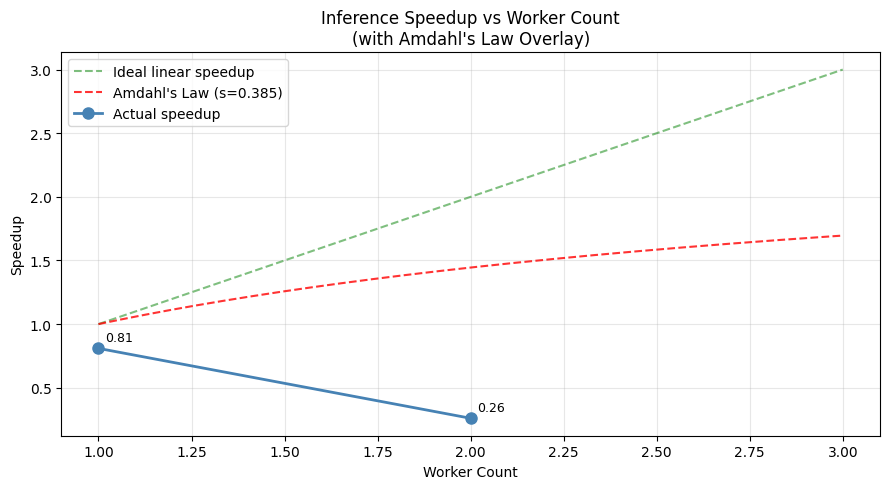

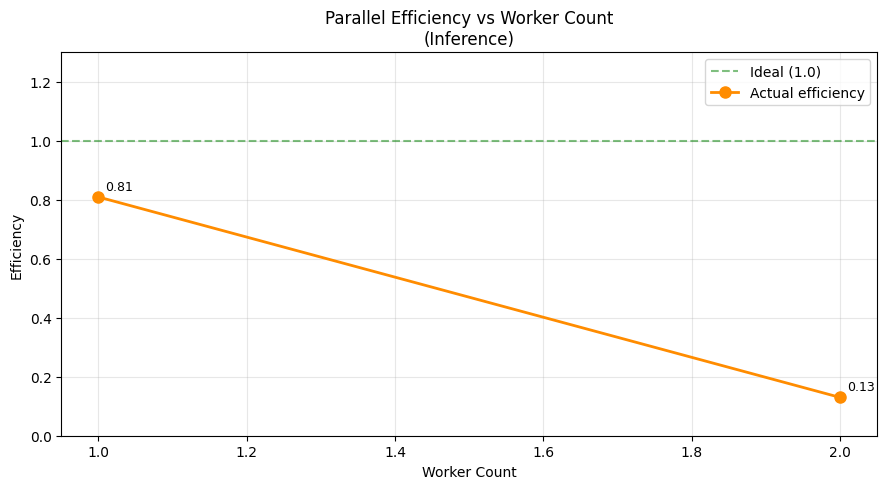

In [17]:
# ── ANALYTICS: Inference Benchmarking — Speedup, Efficiency, Amdahl ───────────
# Uses the same benchmark label count as M2 sequential benchmark if available.
# Worker counts are dynamically generated from connected workers.
# Adds Amdahl's Law overlay to speedup plot.

import json, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import as_completed

# Load serial fraction from M2 sequential benchmark if available
_seq_data = {}
try:
    with open("sequential_benchmark.json") as f:
        _seq_data = json.load(f)
    print(f"Loaded sequential_benchmark.json — serial fraction = {_seq_data.get('serial_fraction_estimate', 'N/A')}")
except FileNotFoundError:
    print("sequential_benchmark.json not found — will estimate serial fraction from scatter time.")

BENCHMARK_LABEL_COUNT = min(300, len(model_payload_items))
benchmark_items = model_payload_items[:BENCHMARK_LABEL_COUNT]

def benchmark_sequential(items, x_eval, threshold=0.5):
    import time, pickle
    start = time.time()
    positive_total = 0
    for _, _, model_bytes in items:
        model = pickle.loads(model_bytes)
        probs = model.predict_proba(x_eval)[:, 1]
        positive_total += int((probs >= threshold).sum())
    return round(time.time() - start, 3), positive_total

def benchmark_worker_batch(items, x_eval, threshold=0.5):
    import pickle, numpy as np
    positive_total = 0
    for _, _, model_bytes in items:
        model = pickle.loads(model_bytes)
        probs = model.predict_proba(x_eval)[:, 1]
        positive_total += int((probs >= threshold).sum())
    return positive_total

def split_even(items, n):
    n = max(1, int(n))
    k, m = divmod(len(items), n)
    out, start = [], 0
    for i in range(n):
        end = start + k + (1 if i < m else 0)
        if start < end:
            out.append(items[start:end])
        start = end
    return out

# Sequential baseline
seq_time, seq_pos = benchmark_sequential(benchmark_items, X_test_sparse, THRESHOLD)
print(f"Sequential benchmark — labels: {BENCHMARK_LABEL_COUNT}  time: {seq_time}s")

# Dynamic worker counts
available_n = len(active_workers)
worker_counts_to_test = sorted(set(
    [2**i for i in range(int(math.log2(available_n))+1) if 2**i <= available_n] + [available_n]
))
print(f"Worker counts to test: {worker_counts_to_test}")

benchmark_rows = []
for n in worker_counts_to_test:
    selected_workers = active_workers[:n]
    parts = split_even(benchmark_items, n)

    t0 = time.time()
    futs = []
    for i, part in enumerate(parts):
        fut = client.submit(
            benchmark_worker_batch, part, X_test_ref, THRESHOLD,
            workers=[selected_workers[i % n]], pure=False
        )
        futs.append(fut)

    dist_pos = 0
    for fut in as_completed(futs):
        dist_pos += int(fut.result())

    dist_time  = round(time.time() - t0, 3)
    speedup    = (seq_time / dist_time) if dist_time > 0 else float('nan')
    efficiency = (speedup / n) if n > 0 else float('nan')

    # Communication fraction for this worker count
    comm_frac = scatter_time_sec / (scatter_time_sec + dist_time) if (scatter_time_sec + dist_time) > 0 else 0

    benchmark_rows.append({
        "worker_count"       : n,
        "seq_time_sec"       : seq_time,
        "dist_time_sec"      : dist_time,
        "scatter_time_sec"   : scatter_time_sec,
        "compute_time_sec"   : round(dist_time - min(scatter_time_sec, dist_time), 3),
        "speedup"            : round(speedup, 4),
        "efficiency"         : round(efficiency, 4),
        "comm_fraction"      : round(comm_frac, 4),
        "seq_positive_count" : seq_pos,
        "dist_positive_count": dist_pos,
    })
    print(f"  Workers={n} | dist={dist_time}s | speedup={speedup:.3f} | eff={efficiency:.3f}")

benchmark_df = pd.DataFrame(benchmark_rows).sort_values("worker_count")
BENCHMARK_CSV = ROOT / "milestone3_benchmark.csv"
benchmark_df.to_csv(BENCHMARK_CSV, index=False)
print(f"\nBenchmark results saved: {BENCHMARK_CSV}")
display(benchmark_df)

# ── Amdahl serial fraction ─────────────────────────────────────────────────────
s_est = _seq_data.get("serial_fraction_estimate", None)
if s_est is None:
    # Estimate from scatter time
    avg_dist = benchmark_df["dist_time_sec"].mean()
    s_est = scatter_time_sec / (scatter_time_sec + avg_dist) if (scatter_time_sec + avg_dist) > 0 else 0.05
    s_est = max(0.001, min(s_est, 0.99))
print(f"Serial fraction used for Amdahl: {s_est:.4f} ({s_est*100:.2f}%)")

p_range  = np.linspace(1, max(worker_counts_to_test) * 1.5, 300)
amdahl   = 1 / (s_est + (1 - s_est) / p_range)
ideal    = p_range

wc = benchmark_df["worker_count"].tolist()
sp = benchmark_df["speedup"].tolist()
ef = benchmark_df["efficiency"].tolist()

# ── Plot 1: Speedup + Amdahl + Ideal ──────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(p_range, ideal,  'g--', alpha=0.5, linewidth=1.5, label='Ideal linear speedup')
plt.plot(p_range, amdahl, 'r--', alpha=0.8, linewidth=1.5, label=f"Amdahl's Law (s={s_est:.3f})")
plt.plot(wc, sp, 'o-', color='steelblue', linewidth=2, markersize=8, label='Actual speedup')
for x, y in zip(wc, sp):
    plt.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.title("Inference Speedup vs Worker Count\n(with Amdahl's Law Overlay)", fontsize=12)
plt.xlabel("Worker Count")
plt.ylabel("Speedup")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("milestone3_speedup.png", dpi=150)
plt.show()

# ── Plot 2: Efficiency ─────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.axhline(1.0, color='g', linestyle='--', alpha=0.5, label='Ideal (1.0)')
plt.plot(wc, ef, 'o-', color='darkorange', linewidth=2, markersize=8, label='Actual efficiency')
for x, y in zip(wc, ef):
    plt.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.title("Parallel Efficiency vs Worker Count\n(Inference)", fontsize=12)
plt.xlabel("Worker Count")
plt.ylabel("Efficiency")
plt.ylim(0, 1.3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("milestone3_efficiency.png", dpi=150)
plt.show()


## Analytics — Communication Cost Breakdown
Breaks total inference runtime into scatter (network) time vs compute time for each worker count. Saved as `communication_breakdown.png`.

Communication Cost Breakdown
  Workers=1 | scatter=6.101s (249.4%) | compute=0.000s | total=2.446s
  Workers=2 | scatter=6.101s (80.1%) | compute=1.515s | total=7.616s


C:\Users\786 Computers\AppData\Local\Temp\ipykernel_6928\846904435.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


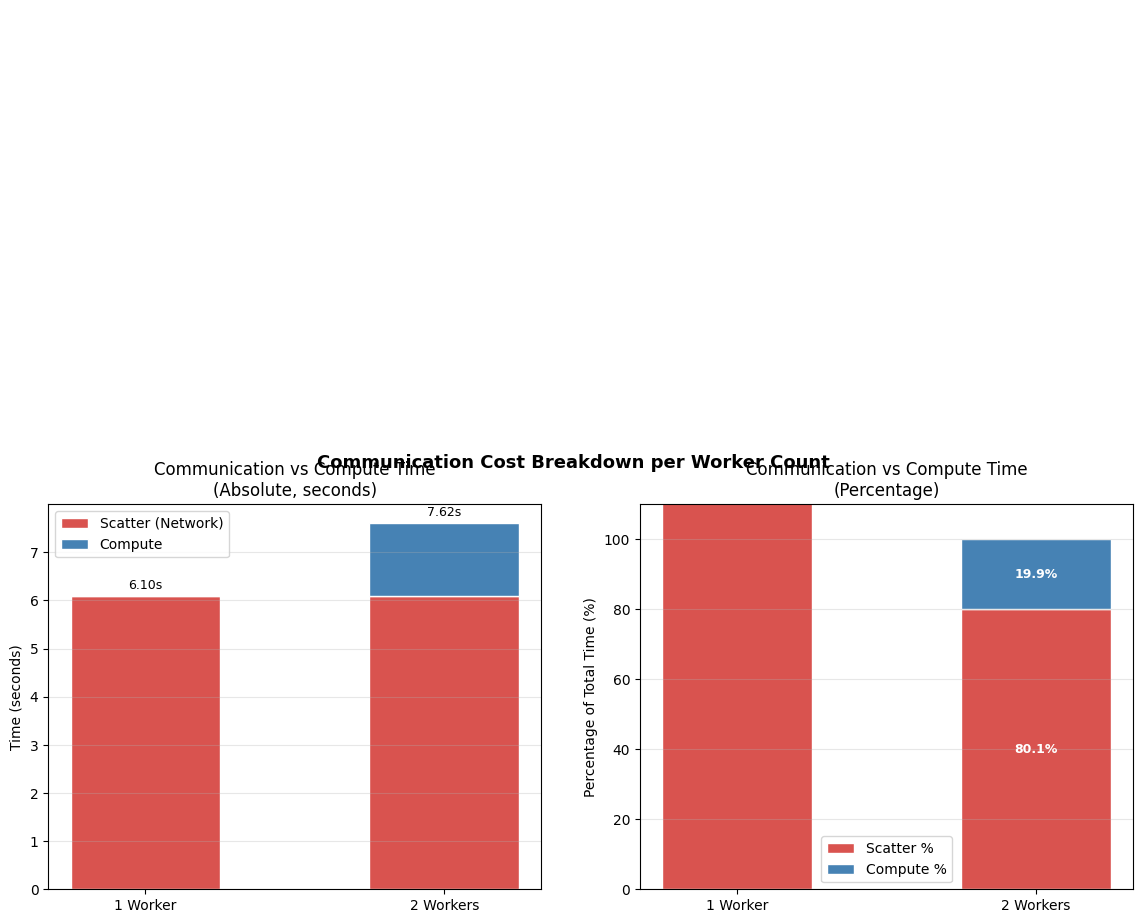

Saved: communication_breakdown.png


In [18]:
# ── ANALYTICS: Communication Cost Breakdown ────────────────────────────────────
# Plots scatter time vs compute time per worker count from benchmark results.
# scatter_time_sec was measured in the cluster connection cell.

import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("Communication Cost Breakdown")
print("=" * 60)

if benchmark_df.empty:
    print("No benchmark data available.")
else:
    wc_list      = benchmark_df["worker_count"].tolist()
    scatter_vals = [scatter_time_sec] * len(wc_list)  # scatter is fixed (broadcast)
    compute_vals = benchmark_df["compute_time_sec"].tolist()
    total_vals   = benchmark_df["dist_time_sec"].tolist()

    for w, s, c, t in zip(wc_list, scatter_vals, compute_vals, total_vals):
        pct = s/t*100 if t > 0 else 0
        print(f"  Workers={w} | scatter={s:.3f}s ({pct:.1f}%) | compute={c:.3f}s | total={t:.3f}s")

    x      = np.arange(len(wc_list))
    width  = 0.5
    labels = [f"{n} Worker{'s' if n>1 else ''}" for n in wc_list]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stacked bar — absolute seconds
    b1 = axes[0].bar(x, scatter_vals, width, label='Scatter (Network)', color='#d9534f', edgecolor='white')
    b2 = axes[0].bar(x, compute_vals, width, bottom=scatter_vals, label='Compute', color='steelblue', edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_title("Communication vs Compute Time\n(Absolute, seconds)")
    axes[0].set_ylabel("Time (seconds)")
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    for xi, (sv, cv) in enumerate(zip(scatter_vals, compute_vals)):
        total = sv + cv
        axes[0].text(xi, total + max(total_vals)*0.01, f'{total:.2f}s',
                     ha='center', va='bottom', fontsize=9)

    # Stacked bar — percentage
    scatter_pct = [s/t*100 if t > 0 else 0 for s, t in zip(scatter_vals, total_vals)]
    compute_pct = [c/t*100 if t > 0 else 0 for c, t in zip(compute_vals, total_vals)]
    axes[1].bar(x, scatter_pct, width, label='Scatter %', color='#d9534f', edgecolor='white')
    axes[1].bar(x, compute_pct, width, bottom=scatter_pct, label='Compute %', color='steelblue', edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_title("Communication vs Compute Time\n(Percentage)")
    axes[1].set_ylabel("Percentage of Total Time (%)")
    axes[1].set_ylim(0, 110)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    for xi, (sp, cp) in enumerate(zip(scatter_pct, compute_pct)):
        axes[1].text(xi, sp/2, f'{sp:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        axes[1].text(xi, sp + cp/2, f'{cp:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.suptitle("Communication Cost Breakdown per Worker Count", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("communication_breakdown.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: communication_breakdown.png")


Saving milestone 3 manifests and summary metrics while closing the distributed client cleanly after prediction and benchmarking.

In [19]:

manifest_m3 = {
    "milestone": 3,
    "test_rows": int(len(predictions_df)),
    "trained_models_used": int(len(model_payload_items)),
    "threshold": float(THRESHOLD),
    "distributed_inference_time_sec": float(inference_time_distributed),
    "rows_without_positive_before_fallback": int(empty_before_fallback),
    "prediction_csv": str(PREDICTION_CSV),
    "prediction_parquet": str(PREDICTION_PARQUET),
    "benchmark_csv": str(BENCHMARK_CSV),
    "speedup_plot": "milestone3_speedup.png",
    "efficiency_plot": "milestone3_efficiency.png",
    "scheduler": f"tcp://{SCHEDULER_IP}:{SCHEDULER_PORT}",
    "worker_count_used": int(len(active_workers)),
}

with open(MANIFEST_M3, "w") as f:
    json.dump(manifest_m3, f, indent=2)

print(f"Milestone 3 manifest saved: {MANIFEST_M3}")
print("Milestone 3 pipeline complete.")

client.close()
print("Dask client closed.")


Milestone 3 manifest saved: milestone3_manifest.json
Milestone 3 pipeline complete.
Dask client closed.
